In [1]:
#Step 1: Create Dataset (10,000 rows)

import numpy as np
import pandas as pd

np.random.seed(42)
n = 10000

data = pd.DataFrame({
    "size": np.random.randint(500, 4000, n),
    "bedrooms": np.random.randint(1, 6, n),
    "age": np.random.randint(0, 30, n),
    "distance": np.random.randint(1, 50, n)
})

data["price"] = (
    data["size"] * 0.05 +
    data["bedrooms"] * 10 -
    data["age"] * 0.7 -
    data["distance"] * 0.5 +
    np.random.normal(0, 10, n)
)

In [2]:
#Step 2: Train-Test Split

from sklearn.model_selection import train_test_split

X = data.drop("price", axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 7.0 MB/s eta 0:00:15
   - -------------------------------------- 2.6/101.7 MB 8.1 MB/s eta 0:00:13
   - -------------------------------------- 4.2/101.7 MB 7.8 MB/s eta 0:00:13
   -- ------------------------------------- 6.0/101.7 MB 8.2 MB/s eta 0:00:12
   --- ------------------------------------ 7.9/101.7 MB 8.3 MB/s eta 0:00:12
   --- ------------------------------------ 9.7/101.7 MB 8.2 MB/s eta 0:00:12
   ---- ----------------------------------- 11.3/101.7 MB 8.3 MB/s eta 0:00:11
   ----- ---------------------------------- 13.1/101.7 MB 8.3 MB/s eta 0:00:11
   ----- ---------------------------------- 14.9/101.7 MB 8.3 MB/s eta 0:00:11
   ------ --------------------------------- 16.5/101.7 MB 8.2 MB/s eta 0:00:11
   ------- -------------------------------- 18.4/101.7 MB 8.2 MB/s eta 0:0


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#Step 3: Train XGBoost Model

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,   # L1 regularization
    reg_lambda=1     # L2 regularization
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
#Step 4: Predictions
y_pred = model.predict(X_test)

In [7]:
#Step 5: Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 10.151037544536832
R2: 0.9642734459726473


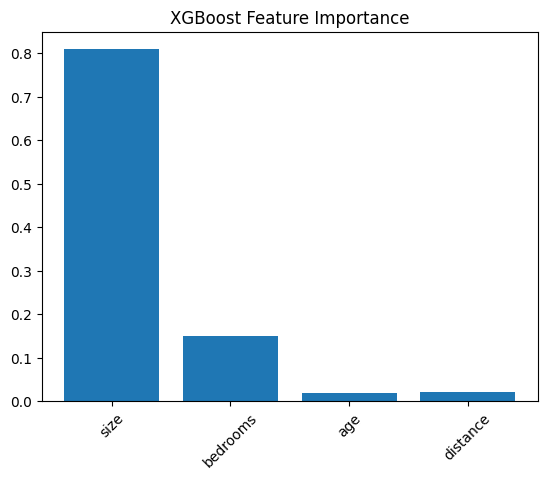

In [8]:
#Step 6: Feature Importance
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45)
plt.show()